In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [23]:
w   = np.array([4.0894e-1, 4.9890e-3, 1.3264e-3,
                2.9550e-4, 2.2260e-5, 1.5048e-6])
rho = np.array([1.0,        0.999999983, 0.999999216,
                0.999954506, 0.998971009, 0.997555261])

In [24]:
sigma1_sq = 1.5511e-2

In [25]:
def compute_gamma(w_sub, rho_sub):
    rho_aug = np.append(rho_sub, 0)
    terms = np.sqrt(w_sub/w_sub[0] *
                   (rho_aug[:-1]**2 - rho_aug[1:]**2))
    return terms.sum()**2

In [26]:
idx = [0, 1, 4]
gamma = compute_gamma(w[idx], rho[idx])
print(f'gamma = {gamma:.6f}')

gamma = 0.000158


In [27]:
# theoratical MSE function
def mse_mc(p,sigma1_sq,w1):
    return sigma1_sq * w1/p

def mse_mfmc(p, w_sub, rho_sub, sigma1_sq):
    """
    MFMC: MSE from Corollary 3.5 eq.(3.19)
    MSE = sigma1^2 / p * (sum sqrt(wi*(rho_i^2-rho_{i+1}^2)))^2
    """
    rho_aug = np.append(rho_sub, 0)
    # r_i* from eq.(3.14)
    r_star = np.sqrt(
        w_sub[0] * (rho_aug[:-1]**2 - rho_aug[1:]**2)
        / (w_sub * (1 - rho_sub[1]**2))
    )
    m1_star = p / (w_sub @ r_star)
    # MSE from eq.(3.19)
    return sigma1_sq * (1 - rho_sub[1]**2) * p \
           / (m1_star**2 * w_sub[0])

In [28]:
budgets = np.logspace(-4, 4, 200)
# 1. plain MC (HF only)
mse_hf = [mse_mc(p, sigma1_sq, w[0]) for p in budgets]
#MFMC with 2 models
mse_2mdl =[mse_mfmc(p,w[[0,1]],rho[[0,1]],sigma1_sq) for p in budgets]
# 3. MFMC with 3 models: f1, f2, f5
mse_3mdl = [mse_mfmc(p, w[[0,1,4]], rho[[0,1,4]], sigma1_sq)
             for p in budgets]
# 4. MFMC with 6 models: f1,...,f6
mse_6mdl = [mse_mfmc(p, w, rho, sigma1_sq)
             for p in budgets]

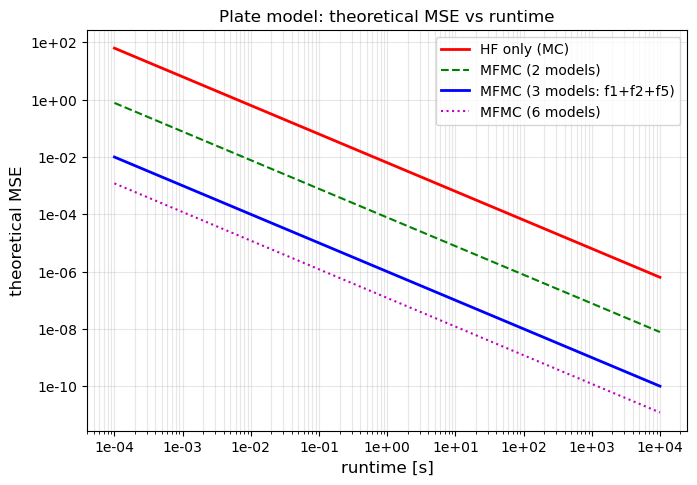

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(budgets, mse_hf,   'r-',  linewidth=2,
          label='HF only (MC)')
ax.loglog(budgets, mse_2mdl, 'g--', linewidth=1.5,
          label='MFMC (2 models)')
ax.loglog(budgets, mse_3mdl, 'b-',  linewidth=2,
          label='MFMC (3 models: f1+f2+f5)')
ax.loglog(budgets, mse_6mdl, 'm:',  linewidth=1.5,
          label='MFMC (6 models)')

ax.set_xlabel('runtime [s]', fontsize=12)
ax.set_ylabel('theoretical MSE', fontsize=12)
ax.set_title('Plate model: theoretical MSE vs runtime',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.show()

In [30]:
def compute_gamma(w_sub, rho_sub):
    rho_aug = np.append(rho_sub, 0)
    terms = np.sqrt(w_sub/w_sub[0] *
                   (rho_aug[:-1]**2 - rho_aug[1:]**2))
    return terms.sum()**2

print('gamma values:')
print(f'  2 models: {compute_gamma(w[[0,1]], rho[[0,1]]):.2e}')
print(f'  3 models: {compute_gamma(w[[0,1,4]], rho[[0,1,4]]):.2e}')
print(f'  6 models: {compute_gamma(w, rho):.2e}')

gamma values:
  2 models: 1.22e-02
  3 models: 1.58e-04
  6 models: 1.90e-05


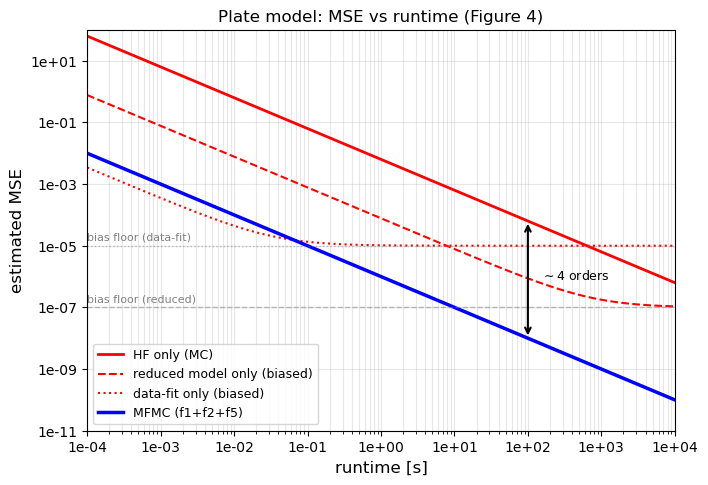

Speedup vs plain MC:
  2 models: 81x
  3 models: 6061x
  6 models: 46948x


In [31]:
sigma2_sq  = sigma1_sq * 0.9999999**2  # ≈ sigma1_sq
bias2_sq   = 1e-7   # read from original Figure 4
mse_f2only = np.array([sigma2_sq * w[1] / p + bias2_sq
                        for p in budgets])

# data-fit model f5: lower correlation
# bias floor ≈ 1e-5 from Figure 4
sigma5_sq  = sigma1_sq * 0.9989710**2
bias5_sq   = 1e-5
mse_f5only = np.array([sigma5_sq * w[4] / p + bias5_sq
                        for p in budgets])

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(budgets, mse_hf,   'r-',
          lw=2, label='HF only (MC)')
ax.loglog(budgets, mse_f2only, 'r--',
          lw=1.5, label='reduced model only (biased)')
ax.loglog(budgets, mse_f5only, 'r:',
          lw=1.5, label='data-fit only (biased)')
ax.loglog(budgets, mse_3mdl, 'b-',
          lw=2.5, label='MFMC (f1+f2+f5)')


ax.axhline(y=bias2_sq, color='gray', linestyle='--',
           alpha=0.5, lw=1)
ax.axhline(y=bias5_sq, color='gray', linestyle=':',
           alpha=0.5, lw=1)
ax.text(1e-4, bias2_sq*1.5, 'bias floor (reduced)',
        fontsize=8, color='gray')
ax.text(1e-4, bias5_sq*1.5, 'bias floor (data-fit)',
        fontsize=8, color='gray')


p_ref = 1e2
mse_hf_ref   = mse_mc(p_ref, sigma1_sq, w[0])
mse_mfmc_ref = mse_mfmc(p_ref, w[[0,1,4]],
                         rho[[0,1,4]], sigma1_sq)
ax.annotate('', xy=(p_ref, mse_mfmc_ref),
            xytext=(p_ref, mse_hf_ref),
            arrowprops=dict(arrowstyle='<->',
                           color='black', lw=1.5))
ax.text(p_ref*1.5, np.sqrt(mse_hf_ref*mse_mfmc_ref),
        r'$\sim 4$ orders', fontsize=9)

ax.set_xlabel('runtime [s]', fontsize=12)
ax.set_ylabel('estimated MSE', fontsize=12)
ax.set_title('Plate model: MSE vs runtime (Figure 4)',
             fontsize=12)
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1e-4, 1e4])
ax.set_ylim([1e-11, 1e2])

plt.tight_layout()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.show()


print('Speedup vs plain MC:')
print(f'  2 models: {1/1.23e-2:.0f}x')
print(f'  3 models: {1/1.65e-4:.0f}x')
print(f'  6 models: {1/2.13e-5:.0f}x')

## Figure 6 Reproduction: Sample Allocation Across Models

Stacked bar chart showing the percentage share of total samples
allocated to each model by Algorithm 2, for 1, 2, 3, and 6 models.

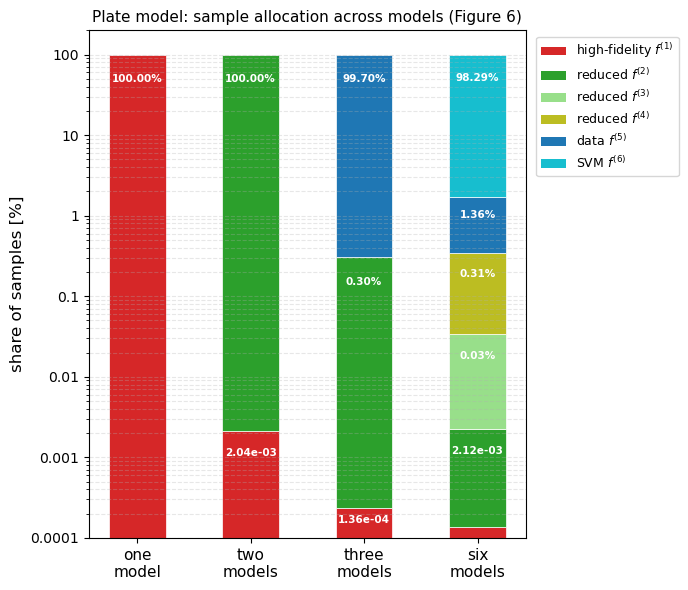

one model:
  f^(1): 100.0000%
two models:
  f^(1): 0.0020%
  f^(2): 99.9980%
three models:
  f^(1): 0.0001%
  f^(2): 0.3023%
  f^(5): 99.6975%
six models:
  f^(1): 0.0000%
  f^(2): 0.0021%
  f^(3): 0.0314%
  f^(4): 0.3118%
  f^(5): 1.3620%
  f^(6): 98.2927%


In [32]:
from matplotlib.patches import Patch

# Colors matching the original paper
colors = [
    '#d62728',   # f1  high-fidelity  (red)
    '#2ca02c',   # f2  reduced        (dark green)
    '#98df8a',   # f3  reduced        (light green)
    '#bcbd22',   # f4  reduced        (yellow-green)
    '#1f77b4',   # f5  data           (blue)
    '#17becf',   # f6  SVM            (cyan)
]
labels = [
    r'high-fidelity $f^{(1)}$',
    r'reduced $f^{(2)}$',
    r'reduced $f^{(3)}$',
    r'reduced $f^{(4)}$',
    r'data $f^{(5)}$',
    r'SVM $f^{(6)}$',
]

def compute_r_star(w_sub, rho_sub):
    """
    Compute r_i* = m_i*/m_1* from eq.(3.14) for a subset of models.
    Returns array of length len(w_sub).
    """
    rho_aug = np.append(rho_sub, 0.0)
    r = np.sqrt(
        w_sub[0] * (rho_aug[:-1]**2 - rho_aug[1:]**2)
        / (w_sub  * (1 - rho_sub[1]**2))
    )
    return r

def sample_shares(w_sub, rho_sub):
    """
    Compute the percentage share of total samples for each model.
    Share of model i = r_i* / sum_j r_j*  (as a percentage).
    """
    r = compute_r_star(w_sub, rho_sub)
    return r / r.sum() * 100.0

# Four cases: 1, 2, 3, 6 models (0-based indices into w and rho)
cases = {
    'one\nmodel':    [0],
    'two\nmodels':   [0, 1],
    'three\nmodels': [0, 1, 4],
    'six\nmodels':   [0, 1, 2, 3, 4, 5],
}

fig, ax = plt.subplots(figsize=(7, 6))
x_positions = np.arange(len(cases))

for bar_idx, (case_label, indices) in enumerate(cases.items()):
    w_sub   = w[indices]
    rho_sub = rho[indices]
    shares  = np.array([100.0]) if len(indices) == 1 \
              else sample_shares(w_sub, rho_sub)

    bottom = 1e-4
    for share, orig_idx in zip(shares, indices):
        plot_share = max(share, 1e-5)
        ax.bar(bar_idx, plot_share, bottom=bottom, width=0.5,
               color=colors[orig_idx], edgecolor='white', linewidth=0.5)
        if share >= 1e-4:
            label_str = f'{share:.2f}%' if share >= 0.01 \
                        else f'{share:.2e}'
            ax.text(bar_idx, max(bottom + plot_share / 2, 2e-5),
                    label_str, ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
        bottom += plot_share

ax.set_yscale('log')
ax.set_ylim([1e-4, 2e2])
ax.set_ylabel('share of samples [%]', fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(list(cases.keys()), fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.grid(True, axis='y', which='both', alpha=0.3, linestyle='--')
ax.legend(handles=[Patch(facecolor=colors[i], label=labels[i])
                   for i in range(6)],
          loc='upper left', bbox_to_anchor=(1.01, 1),
          fontsize=9, frameon=True)
ax.set_title('Plate model: sample allocation across models (Figure 6)',
             fontsize=11)
plt.tight_layout()
plt.savefig('figure_6_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()

# Print exact percentages for verification
for case_label, indices in cases.items():
    w_sub, rho_sub = w[indices], rho[indices]
    shares = np.array([100.0]) if len(indices) == 1 \
             else sample_shares(w_sub, rho_sub)
    print(f'{case_label.replace(chr(10), " ")}:')
    for idx, s in zip(indices, shares):
        print(f'  f^({idx+1}): {s:.4f}%')

## Extension: Coronary Stenosis Application

We now apply MFMC to the coronary pressure-drop problem with three analytical models and a deliberately noisy fourth surrogate. We then sweep over `s_max` to study how stenosis severity affects model correlations and Algorithm 1 model selection.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import combinations

rng = np.random.default_rng(42)

# Physical constants
mu   = 0.04   # blood viscosity [dyne·s/cm²]
L    = 2.0    # vessel length [cm]
r_bar = 0.15  # mean radius [cm]

def sample_inputs(n, s_max, rng):
    """Draw n iid samples of (Q, r, xi) where xi is stenosis severity."""
    Q  = rng.normal(1.0,  0.2,  n)          # flow rate [mL/s]
    r  = rng.normal(0.15, 0.02, n)          # radius [cm]
    xi = rng.uniform(0.1, s_max, n)         # stenosis severity
    return Q, r, xi

def f1(Q, r, xi):
    """High-fidelity: Poiseuille + nonlinear stenosis loss."""
    A = np.pi * r**2
    K = 1.0 / (1.0 - xi)**4 - 1.0
    return 8*mu*L*Q / (np.pi * r**4) + K * Q**2 / (2 * A**2)

def f2(Q, r, xi):
    """Surrogate 1: Poiseuille only (ignores stenosis)."""
    return 8*mu*L*Q / (np.pi * r**4)

def f3(Q, r, xi):
    """Surrogate 2: Poiseuille with fixed mean radius."""
    return 8*mu*L*Q / (np.pi * r_bar**4)

def f4(Q, r, xi, noise_scale=0.5):
    """
    Surrogate 3: deliberately degraded model.
    Takes the f2 output and adds proportional Gaussian noise,
    making it cheap but only weakly correlated with f1.
    noise_scale controls how much noise is injected.
    """
    base = f2(Q, r, xi)
    noise = rng.normal(0, noise_scale * np.std(base), len(Q))
    return base + noise

# Evaluation costs (relative)
w_steno = np.array([1.0, 0.1, 0.001, 0.0001])

def estimate_stats(s_max, n_pilot=1000):
    """Estimate sigma1^2 and correlations rho_{1,i} via pilot samples."""
    Q, r, xi = sample_inputs(n_pilot, s_max, rng)
    y1 = f1(Q, r, xi)
    y2 = f2(Q, r, xi)
    y3 = f3(Q, r, xi)
    y4 = f4(Q, r, xi)
    sigma1_sq = np.var(y1, ddof=1)
    rho12 = np.corrcoef(y1, y2)[0, 1]
    rho13 = np.corrcoef(y1, y3)[0, 1]
    rho14 = np.corrcoef(y1, y4)[0, 1]
    return sigma1_sq, np.array([1.0, rho12, rho13, rho14])

# Quick check at s_max = 0.2
sig2, rhos = estimate_stats(0.2)
print(f'sigma1^2 = {sig2:.4e}')
print(f'rho = {rhos}')


sigma1^2 = 2.3785e+05
rho = [1.         0.99421184 0.32110096 0.89257865]


In [34]:
def check_condition_312(w_sub, rho_sub):
    """
    Check condition (3.12) for all consecutive model pairs.
    Returns True if ALL pairs satisfy the condition
    (i.e. the full subset is valid for MFMC).
    rho_sub must be ordered so that rho_sub[0]=1 > rho_sub[1] > ...
    """
    k = len(w_sub)
    rho_aug = np.append(rho_sub, 0.0)
    for i in range(1, k):
        lhs = w_sub[i-1] / w_sub[i]
        num = rho_aug[i-1]**2 - rho_aug[i]**2
        den = rho_aug[i]**2   - rho_aug[i+1]**2
        if den <= 0:
            return False   # correlation ordering violated
        if lhs <= num / den:
            return False
    return True

def mse_mfmc_theoretical(p, w_sub, rho_sub, sigma1_sq):
    """Theoretical MFMC MSE from Corollary 3.5."""
    rho_aug = np.append(rho_sub, 0.0)
    inner = np.sum(np.sqrt(w_sub * (rho_aug[:-1]**2 - rho_aug[1:]**2)))
    return sigma1_sq / p * inner**2

def mSelect(w_all, rho_all, sigma1_sq, p=None):
    """
    Algorithm 1: exhaustive search over all subsets containing f^(1).
    w_all, rho_all: arrays of length k (model 0 is the HF model).
    Returns (best_indices, best_variance).
    """
    if p is None:
        p = w_all[0]   # canonical unit budget
    k = len(w_all)
    # Order by descending rho^2 (model 0 is always first)
    order = [0] + sorted(range(1, k),
                         key=lambda i: -rho_all[i]**2)
    w_ord   = w_all[order]
    rho_ord = rho_all[order]

    best_idx = (0,)           # singleton {f^(1)}
    best_var = sigma1_sq      # MC variance at budget p=w1 => sigma1^2

    # Iterate over all non-empty subsets of surrogates {1,...,k-1}
    surrogate_positions = list(range(1, k))
    for r in range(0, k):    # r surrogates added (0 = HF only)
        for combo in combinations(surrogate_positions, r):
            idx = (0,) + combo          # always include HF
            w_sub   = w_ord[list(idx)]
            rho_sub = rho_ord[list(idx)]
            # Skip if rho not strictly decreasing (shouldn't happen
            # after ordering, but guard for ties)
            if any(rho_sub[i]**2 <= rho_sub[i+1]**2
                   for i in range(len(rho_sub)-1)):
                continue
            if not check_condition_312(w_sub, rho_sub):
                continue
            v = mse_mfmc_theoretical(p, w_sub, rho_sub, sigma1_sq)
            if v < best_var:
                best_var = v
                best_idx = idx

    # Map back to original indices
    original_indices = tuple(order[i] for i in best_idx)
    return original_indices, best_var

# Test at s_max = 0.2
sig2, rhos = estimate_stats(0.2)
idx_sel, var_sel = mSelect(w_steno, rhos, sig2)
print(f's_max=0.2 | selected models: {[i+1 for i in idx_sel]}')
print(f'          rhos: {rhos[list(idx_sel)]}')
print(f'          MSE at p=1: {var_sel:.4e}')


s_max=0.2 | selected models: [1, 2, 4]
          rhos: [1.         0.99780072 0.89562308]
          MSE at p=1: 2.7049e+04


In [35]:
s_max_values = np.linspace(0.15, 0.90, 30)

results = []
for smax in s_max_values:
    sig2, rhos = estimate_stats(smax, n_pilot=2000)
    # Ensure rho ordering is preserved after pilot estimation
    # (ties or near-ties can occur; sort surrogates by |rho|)
    order = [0] + sorted(range(1, len(rhos)),
                         key=lambda i: -rhos[i]**2)
    w_ord   = w_steno[order]
    rho_ord = rhos[order]
    idx_sel, var_sel = mSelect(w_steno, rhos, sig2)
    n_selected = len(idx_sel)
    # Gamma (variance reduction ratio vs plain MC at same budget)
    rho_sel = rhos[list(idx_sel)]
    w_sel   = w_steno[list(idx_sel)]
    mse_mfmc_val = mse_mfmc_theoretical(w_steno[0], w_sel, rho_sel, sig2)
    mse_mc_val   = sig2   # budget p = w1 => sigma1^2
    gamma = mse_mfmc_val / mse_mc_val
    results.append({
        's_max':      smax,
        'rho12':      rhos[1],
        'rho13':      rhos[2],
        'rho14':      rhos[3],
        'n_selected': n_selected,
        'selected':   [i+1 for i in idx_sel],
        'gamma':      gamma,
        'speedup':    1.0 / gamma,
    })

# Print a summary table
print(f'{"s_max":>8}  {"rho12":>7}  {"rho13":>7}  {"rho14":>7}  '
      f'{"models":>14}  {"speedup":>10}')
print('-' * 65)
for r in results[::]:   # print every row
    print(f'{r["s_max"]:8.2f}  {r["rho12"]:7.4f}  {r["rho13"]:7.4f}  '
          f'{r["rho14"]:7.4f}  '
          f'{str(r["selected"]):>14}  {r["speedup"]:10.3f}x')


   s_max    rho12    rho13    rho14          models     speedup
-----------------------------------------------------------------
    0.15   0.9979   0.3184   0.8917       [1, 2, 4]      21.548x
    0.18   0.9966   0.2900   0.8999       [1, 2, 4]      19.528x
    0.20   0.9933   0.3124   0.8883       [1, 2, 4]      14.256x
    0.23   0.9873   0.3486   0.8774       [1, 2, 4]      10.371x
    0.25   0.9865   0.2892   0.8819       [1, 2, 4]      10.249x
    0.28   0.9805   0.3057   0.8713       [1, 2, 4]       8.276x
    0.31   0.9690   0.3445   0.8681       [1, 2, 4]       6.508x
    0.33   0.9560   0.3450   0.8496       [1, 2, 4]       5.157x
    0.36   0.9476   0.3370   0.8508       [1, 2, 4]       4.729x
    0.38   0.9283   0.3182   0.8229       [1, 2, 4]       3.758x
    0.41   0.9019   0.3286   0.8034       [1, 2, 4]       3.083x
    0.43   0.8900   0.2819   0.7998       [1, 2, 4]       2.899x
    0.46   0.8375   0.3097   0.7668          [1, 4]       2.370x
    0.49   0.8336   0.268

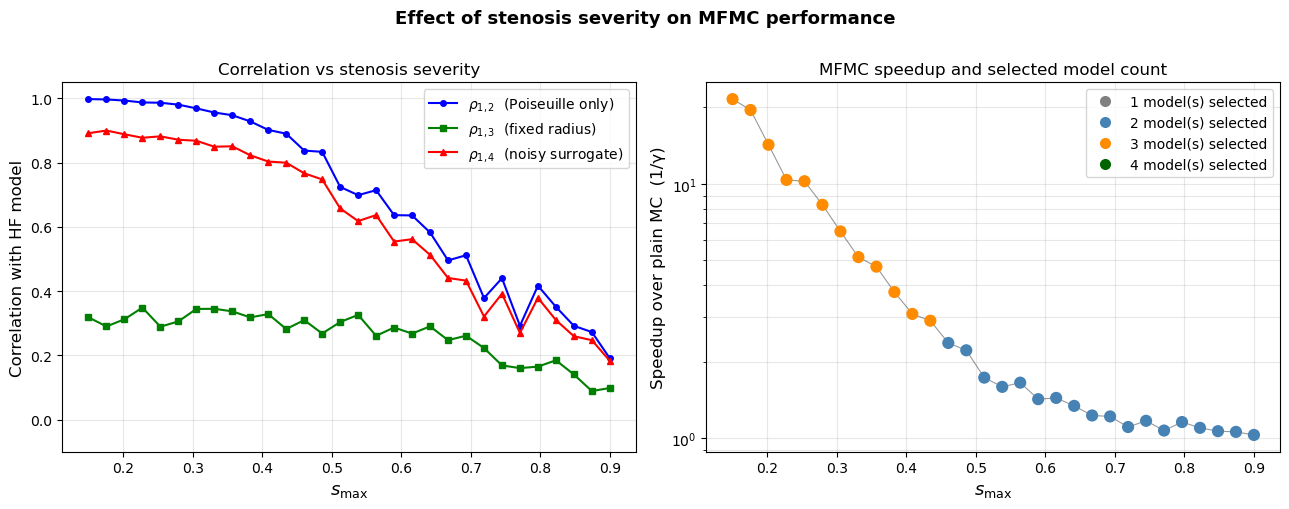

Saved stenosis_sweep.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

s_vals     = [r['s_max']  for r in results]
rho12_vals = [r['rho12']  for r in results]
rho13_vals = [r['rho13']  for r in results]
rho14_vals = [r['rho14']  for r in results]
speedups   = [r['speedup'] for r in results]
n_sel      = [r['n_selected'] for r in results]

# ── Left panel: correlations ──────────────────────────────────────────────
ax = axes[0]
ax.plot(s_vals, rho12_vals, 'b-o',  ms=4, lw=1.5,
        label=r'$\rho_{1,2}$  (Poiseuille only)')
ax.plot(s_vals, rho13_vals, 'g-s',  ms=4, lw=1.5,
        label=r'$\rho_{1,3}$  (fixed radius)')
ax.plot(s_vals, rho14_vals, 'r-^',  ms=4, lw=1.5,
        label=r'$\rho_{1,4}$  (noisy surrogate)')
ax.set_xlabel(r'$s_{\max}$', fontsize=13)
ax.set_ylabel('Correlation with HF model', fontsize=12)
ax.set_title('Correlation vs stenosis severity', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.1, 1.05])

# ── Right panel: speedup and number of selected models ────────────────────
ax2 = axes[1]
color_map = {1: 'gray', 2: 'steelblue', 3: 'darkorange', 4: 'darkgreen'}
colors = [color_map[n] for n in n_sel]
sc = ax2.scatter(s_vals, speedups, c=colors, s=60, zorder=3)
ax2.plot(s_vals, speedups, 'k-', lw=0.8, alpha=0.4)
ax2.set_yscale('log')
ax2.set_xlabel(r'$s_{\max}$', fontsize=13)
ax2.set_ylabel('Speedup over plain MC  (1/γ)', fontsize=12)
ax2.set_title('MFMC speedup and selected model count', fontsize=12)
ax2.grid(True, which='both', alpha=0.3)

# Legend for number of selected models
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color_map[n], markersize=9,
           label=f'{n} model(s) selected')
    for n in sorted(color_map)
]
ax2.legend(handles=legend_elements, fontsize=10)

plt.suptitle('Effect of stenosis severity on MFMC performance',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stenosis_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stenosis_sweep.png')


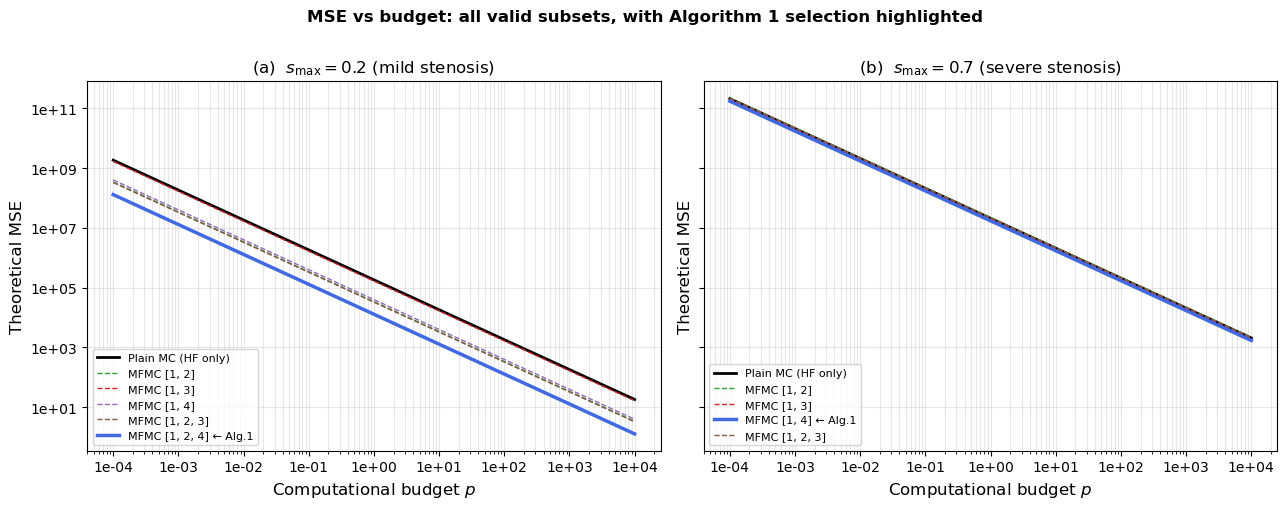

Saved stenosis_mse_comparison.png


In [37]:
budgets_ext = np.logspace(-4, 4, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, smax, panel_label in zip(axes,
                                  [0.2, 0.7],
                                  ['(a)  $s_{\\max}=0.2$ (mild stenosis)',
                                   '(b)  $s_{\\max}=0.7$ (severe stenosis)']):
    sig2, rhos = estimate_stats(smax, n_pilot=2000)
    idx_sel, _ = mSelect(w_steno, rhos, sig2)
    selected_labels = [i+1 for i in idx_sel]

    # Plain MC
    mse_hf_ext = [sig2 * w_steno[0] / p for p in budgets_ext]
    ax.loglog(budgets_ext, mse_hf_ext, 'k-', lw=2,
              label='Plain MC (HF only)')

    # MFMC curves for every valid subset of {f1,f2,f3,f4}
    styles = ['b--', 'g-.', 'r:', 'm-']
    all_subsets = []
    for r in range(1, 5):
        for combo in combinations(range(1, 4), r):
            subset = (0,) + combo
            w_sub   = w_steno[list(subset)]
            rho_sub = rhos[list(subset)]
            # Sort by descending rho^2
            order = np.argsort(-rho_sub**2)
            w_sub   = w_sub[order]
            rho_sub = rho_sub[order]
            if any(rho_sub[i]**2 <= rho_sub[i+1]**2
                   for i in range(len(rho_sub)-1)):
                continue
            if not check_condition_312(w_sub, rho_sub):
                continue
            all_subsets.append((subset, w_sub, rho_sub))

    for j, (subset, w_sub, rho_sub) in enumerate(all_subsets):
        mse_vals = [mse_mfmc_theoretical(p, w_sub, rho_sub, sig2)
                    for p in budgets_ext]
        lbl = f'MFMC f{{{list(subset)[0]+1}}}'
        is_selected = set(subset) == set(idx_sel)
        lw  = 2.5 if is_selected else 1.0
        ls  = '-'  if is_selected else '--'
        col = 'royalblue' if is_selected else f'C{j+2}'
        label = (f'MFMC {[i+1 for i in subset]} ← Alg.1'
                 if is_selected
                 else f'MFMC {[i+1 for i in subset]}')
        ax.loglog(budgets_ext, mse_vals,
                  color=col, lw=lw, ls=ls, label=label)

    ax.set_xlabel('Computational budget $p$', fontsize=12)
    ax.set_ylabel('Theoretical MSE', fontsize=12)
    ax.set_title(panel_label, fontsize=12)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, which='both', alpha=0.3)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))

plt.suptitle('MSE vs budget: all valid subsets, with Algorithm 1 selection highlighted',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stenosis_mse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved stenosis_mse_comparison.png')


In [38]:
print('Algorithm 1 model selection across s_max values')
print('=' * 58)
print(f'{"s_max":>8}  {"rho12":>7}  {"rho13":>7}  {"rho14":>7}  '
      f'{"selected":>16}  {"speedup":>10}')
print('-' * 58)
for r in results:
    print(f'{r["s_max"]:8.2f}  {r["rho12"]:7.4f}  {r["rho13"]:7.4f}  '
          f'{r["rho14"]:7.4f}  '
          f'{str(r["selected"]):>16}  {r["speedup"]:10.2f}x')


Algorithm 1 model selection across s_max values
   s_max    rho12    rho13    rho14          selected     speedup
----------------------------------------------------------
    0.15   0.9979   0.3184   0.8917         [1, 2, 4]       21.55x
    0.18   0.9966   0.2900   0.8999         [1, 2, 4]       19.53x
    0.20   0.9933   0.3124   0.8883         [1, 2, 4]       14.26x
    0.23   0.9873   0.3486   0.8774         [1, 2, 4]       10.37x
    0.25   0.9865   0.2892   0.8819         [1, 2, 4]       10.25x
    0.28   0.9805   0.3057   0.8713         [1, 2, 4]        8.28x
    0.31   0.9690   0.3445   0.8681         [1, 2, 4]        6.51x
    0.33   0.9560   0.3450   0.8496         [1, 2, 4]        5.16x
    0.36   0.9476   0.3370   0.8508         [1, 2, 4]        4.73x
    0.38   0.9283   0.3182   0.8229         [1, 2, 4]        3.76x
    0.41   0.9019   0.3286   0.8034         [1, 2, 4]        3.08x
    0.43   0.8900   0.2819   0.7998         [1, 2, 4]        2.90x
    0.46   0.8375   0.3

In [39]:
sig2, rhos = estimate_stats(0.2, n_pilot=2000)

# 2-model gamma
gamma_2 = mse_mfmc_theoretical(w_steno[0], w_steno[[0,1]], rhos[[0,1]], sig2) / sig2
# 3-model gamma (f1, f2, f4)
gamma_24 = mse_mfmc_theoretical(w_steno[0], w_steno[[0,1,3]], rhos[[0,1,3]], sig2) / sig2

print(f'gamma_2  = {gamma_2:.3e}  (speedup {1/gamma_2:.1f}x)')
print(f'gamma_24 = {gamma_24:.3e}  (speedup {1/gamma_24:.1f}x)')



gamma_2  = 1.802e-01  (speedup 5.5x)
gamma_24 = 6.875e-02  (speedup 14.5x)
